# Экспериментальный спектральный PCA-анализ сейсмического разреза

Этот ноутбук не используется как основной метод выделения разрывных нарушений. PCA применяется к локальным амплитудным спектрам, чтобы сжать спектральные признаки и показать пространственные изменения частотного состава. Такой подход обычно полезнее для стратиграфических и фациальных изменений, чем для прямого детектирования разломов.

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

!pip -q install segyio scikit-learn

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 6.9 MB/s eta 0:00:00


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import segyio
from scipy.signal import stft
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

SEGY_PATH = Path('/content/drive/MyDrive/cw_data/TrainingData_Image.segy')
N_TRACES = 700
WINDOW_SAMPLES = 128
HOP_SAMPLES = 32
N_COMPONENTS = 3

if not SEGY_PATH.exists():
    raise FileNotFoundError(f'SEG-Y не найден: {SEGY_PATH}')

## 1. Загрузка фрагмента и шага дискретизации

In [3]:
def load_first_traces(path: Path, n_traces: int) -> tuple[np.ndarray, float]:
    """Возвращает (sample, trace) и шаг дискретизации в секундах."""
    with segyio.open(str(path), 'r', ignore_geometry=True) as segy:
        count = min(n_traces, len(segy.trace))
        traces = np.stack([
            np.asarray(segy.trace[i], dtype=np.float32)
            for i in range(count)
        ])
        dt_us = float(segyio.tools.dt(segy))

    if dt_us <= 0:
        # Если заголовок SEG-Y не содержит корректного dt, частоты будут в cycles/sample.
        dt_seconds = 1.0
        print('Предупреждение: шаг дискретизации не прочитан; частоты будут в cycles/sample.')
    else:
        dt_seconds = dt_us * 1e-6

    return traces.T, dt_seconds


seismic, dt = load_first_traces(SEGY_PATH, N_TRACES)
scale = np.percentile(np.abs(seismic), 99.5)
seismic_norm = seismic / max(scale, np.finfo(np.float32).eps)
print(f'Разрез: {seismic_norm.shape[0]} × {seismic_norm.shape[1]}, dt={dt:g} s')

Разрез: 1006 × 700, dt=0.003 s


## 2. Локальные спектральные признаки

In [4]:
def local_spectral_features(
    section: np.ndarray,
    dt_seconds: float,
    window_samples: int,
    hop_samples: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    STFT для каждой трассы.

    Возвращает:
      features: (time_window * trace, frequency)
      frequencies: частотная ось
      time_centers: центры окон в отсчётах
    """
    if hop_samples <= 0 or hop_samples > window_samples:
        raise ValueError('HOP_SAMPLES должен быть в диапазоне 1..WINDOW_SAMPLES.')

    fs = 1.0 / dt_seconds
    noverlap = window_samples - hop_samples
    all_features = []
    time_axis = None
    frequencies = None

    for trace_idx in range(section.shape[1]):
        frequencies, times, zxx = stft(
            section[:, trace_idx],
            fs=fs,
            nperseg=window_samples,
            noverlap=noverlap,
            boundary=None,
            padded=False,
        )
        log_power = np.log1p(np.abs(zxx) ** 2).T  # (time_window, frequency)
        all_features.append(log_power)
        if time_axis is None:
            time_axis = times

    # Сначала время, затем трасса — это удобно для обратного reshape после PCA.
    cube = np.stack(all_features, axis=1)  # (time_window, trace, frequency)
    features = cube.reshape(-1, cube.shape[-1])
    time_centers = time_axis / dt_seconds
    return features, frequencies, time_centers


features, frequencies, time_centers = local_spectral_features(
    seismic_norm, dt, WINDOW_SAMPLES, HOP_SAMPLES
)
print(f'Матрица признаков: {features.shape}')

Матрица признаков: (19600, 65)


## 3. PCA спектров

In [5]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

pca = PCA(n_components=N_COMPONENTS, random_state=0)
scores = pca.fit_transform(features_scaled)

n_time = len(time_centers)
n_traces = seismic_norm.shape[1]
pca_maps = scores.reshape(n_time, n_traces, N_COMPONENTS)

print('Доля объяснённой дисперсии:')
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f'  PC{i}: {ratio:.3f}')
print(f'  Сумма: {pca.explained_variance_ratio_.sum():.3f}')

Доля объяснённой дисперсии:
  PC1: 0.181
  PC2: 0.152
  PC3: 0.078
  Сумма: 0.412


## 4. Визуализация компонент

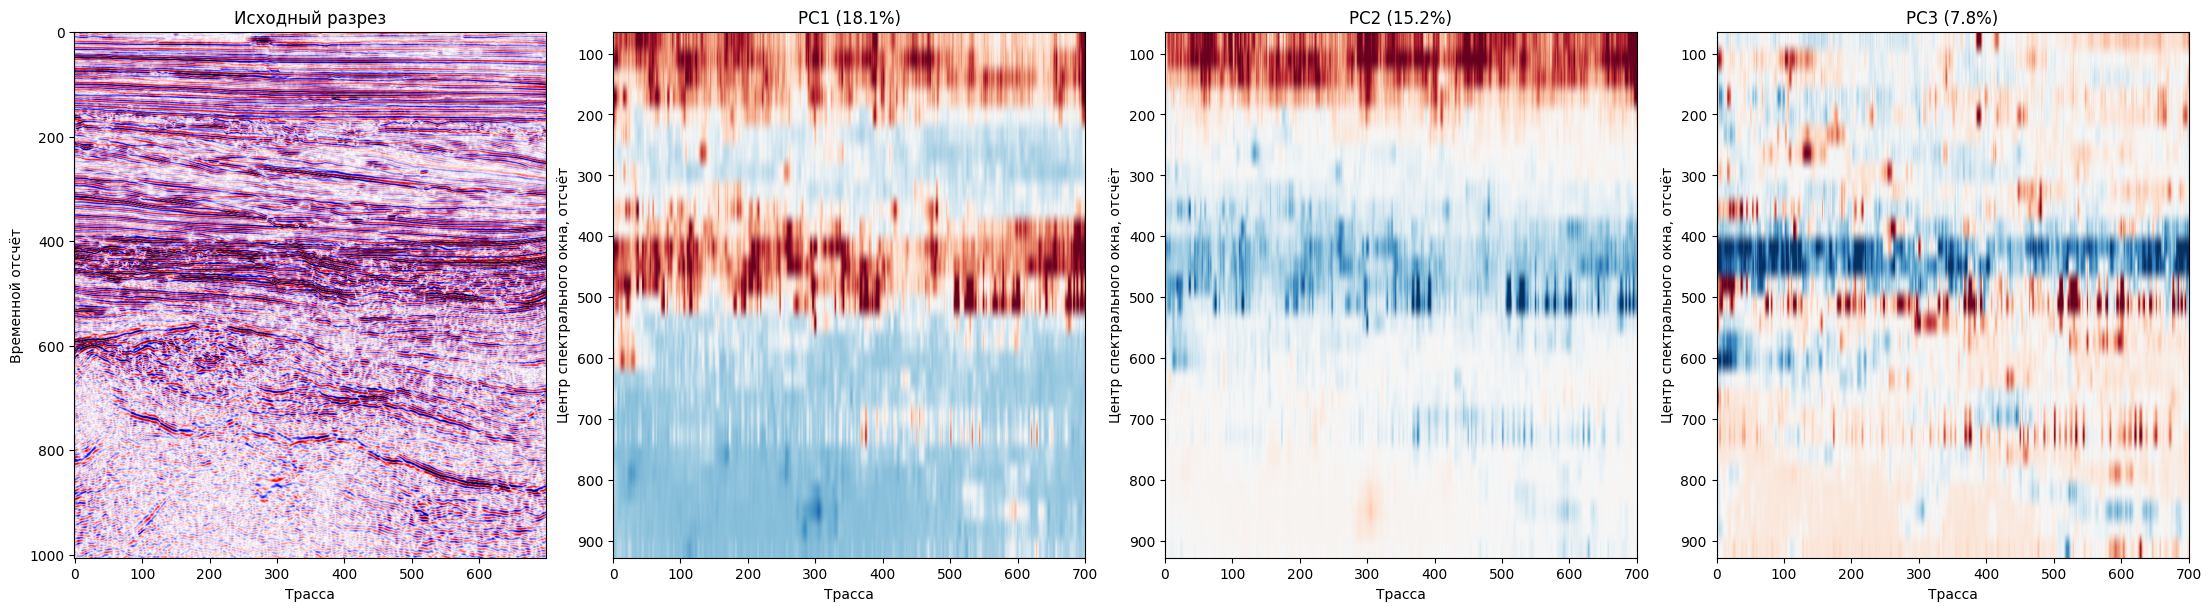

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6), constrained_layout=True)

vmax = np.percentile(np.abs(seismic_norm), 98)
axes[0].imshow(seismic_norm, cmap='seismic', aspect='auto', vmin=-vmax, vmax=vmax)
axes[0].set_title('Исходный разрез')
axes[0].set_ylabel('Временной отсчёт')

extent = [0, n_traces, time_centers[-1], time_centers[0]]
for component_idx in range(N_COMPONENTS):
    component = pca_maps[:, :, component_idx]
    limit = np.percentile(np.abs(component), 98)
    axes[component_idx + 1].imshow(
        component,
        cmap='RdBu_r',
        aspect='auto',
        vmin=-limit,
        vmax=limit,
        extent=extent,
    )
    axes[component_idx + 1].set_title(
        f'PC{component_idx + 1} ({pca.explained_variance_ratio_[component_idx]:.1%})'
    )
    axes[component_idx + 1].set_ylabel('Центр спектрального окна, отсчёт')

for ax in axes:
    ax.set_xlabel('Трасса')

plt.show()

## Вывод по применимости

PCA здесь не является классификатором разломов. Компоненты показывают наиболее сильные режимы изменения
локального спектра. Если геологический объект отличается частотным составом от окружения (например,
стратиграфическая неоднородность, русловое тело, фациальная смена), карта компонент может быть информативной.
Для разрывного нарушения геометрические признаки — когерентность, локальная ориентация, кривизна и т.п. —
обычно интерпретируются прямее. Поэтому этот ноутбук разумно оставлять как **экспериментальный** и не выдавать
его результаты за автоматическое выделение разломов.